In [300]:
# simplest model to test the AHE implementation. 
# two-band Chern insulator (Qi–Wu–Zhang model)
# 2d square lattice
# only the lattice vectors (in Å^-1) are required
# note the units of H are eV and of dH eV Å

In [1]:
using Revise
using Optics_in_the_length_gauge

In [2]:
using StaticArrays, Brillouin, Bravais, CairoMakie

const I2 = @SMatrix [1 0; 0 1]
const σs = [[0 1; 1 0], [0 -im; im 0], [1 0; 0 -1]]

3-element Vector{Matrix{Complex{Int64}}}:
 [0 + 0im 1 + 0im; 1 + 0im 0 + 0im]
 [0 + 0im 0 - 1im; 0 + 1im 0 + 0im]
 [1 + 0im 0 + 0im; 0 + 0im -1 + 0im]

In [4]:
CI_h(μ, k, a; m = 1) = -μ*I2 .+ sin(k[1]*a) .* σs[1] +
    sin(k[2]*a) .* σs[2] + (m + cos(k[1]*a)+ cos(k[2]*a)) .* σs[3] # eV 
CI_dh(k, a0, a::Symbol) = CI_dh(k,  a0, symtoind(a)) #ev Å
function CI_dh(k, a0, a::Int) 
    if a == 1
        a0 * cos(k[1]*a0) .* σs[1] - a0 * sin(k[1]*a0)  .* σs[3]
    elseif a == 2 
       a0 * cos(k[2]*a0) .* σs[2] - a0 * sin(k[2]*a0)  .* σs[3]
    else 
        0 .* I2 
    end
end

 function symtoind(a::Symbol)
    if     a == :x
        1
    elseif a == :y
        2
    elseif a == :z
        3
    end
end


symtoind (generic function with 1 method)

## Bands

In [183]:

using CairoMakie, BZpaths, LinearAlgebra

function bands(i, μ, a, q)
    ϵs, ψs = eigen(CI_h(μ, q, a))   
    return ϵs[i]
end

function bs(μ; a = 1)
    sgnum = 3 # Point group    
    Rs = ([a, 0], [0,a])
    N = 50    #kpoints
    fig = Figure(); ax = Axis(fig[1,1], ylabel = "E [eV]")
    for i in 1:2
        dispersion(q) = bands(i, μ,a, q)
        BZpaths.plot_observable_in_kpath!(ax, dispersion, Rs, sgnum, N)#, high_sym_line high_sym_line = [:Γ, :M, :K, :Γ, :A, :L, :H, :A] )
    end
    fig
end

bs (generic function with 1 method)

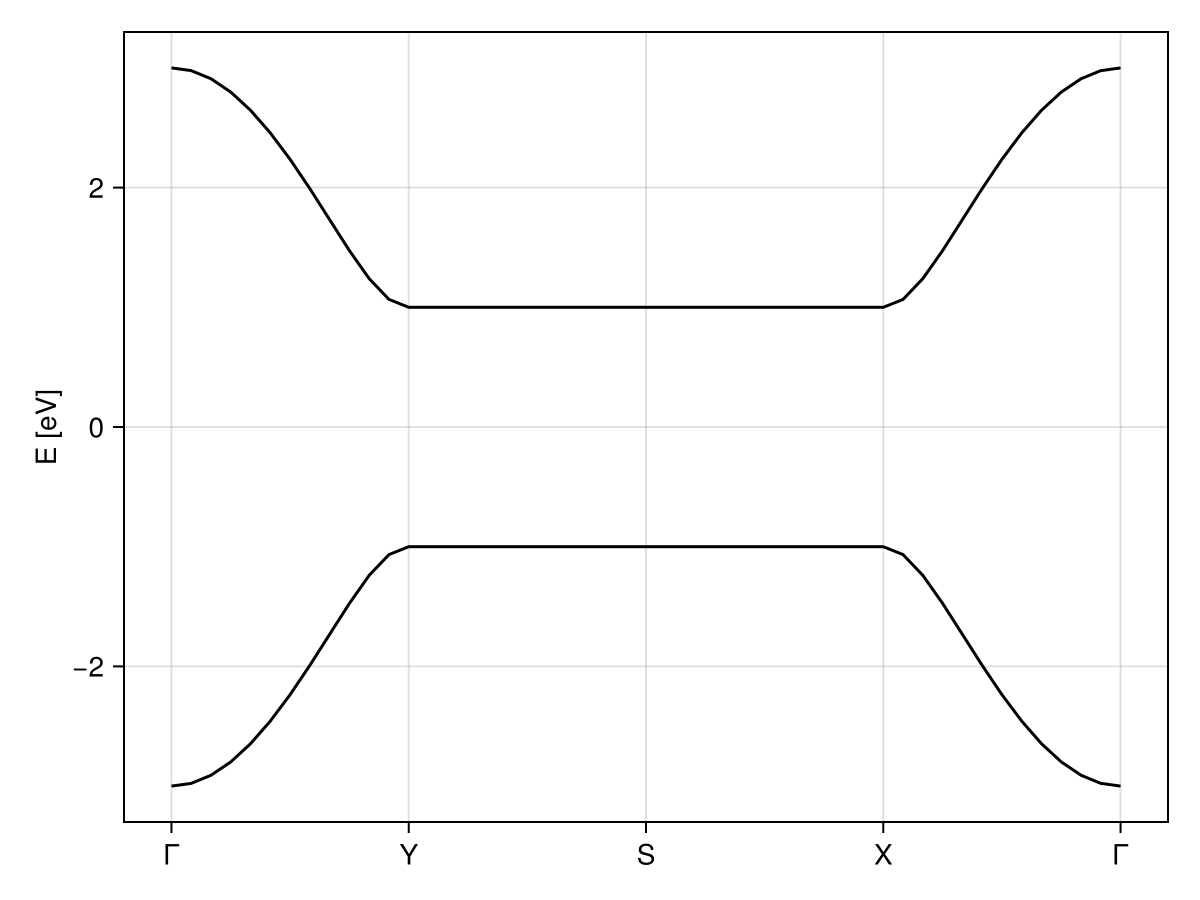

In [184]:
bs(0; a = 2)

## AHE

In [268]:
function ahe_CI(μ; dirj=:x, dirE=:y, T = 1,  evals = 10000, 
    integration_method = :montecarlo, botbounds = [-0.5,-0.5], topbounds = [0.5,0.5])
    a0 = 1 # Å
    Rs = ([a0, 0], [0,a0])
    Gs = dualbasis(Rs)

    # println(Optics_in_the_length_gauge.bz_volume(Gs[1],Gs[2]))
    h(q) = CI_h(μ, q, a0) #in 
    dhx(q) = CI_dh(q, a0,:x)
    dhy(q) = CI_dh(q, a0,:y)
    dhz(q) = CI_dh(q, a0,:z)
    dh(q) = [dhx(q), dhy(q)]
    computation = Transport_computation_3d_presets(botbounds,topbounds, evals, integration_method)
    return AH_presets_3d(a0, dirj, dirE, h, dh, T, computation, Gs)
end


ahe_CI (generic function with 1 method)

In [256]:
p = ahe_CI(0)

AH_presets_3d{SVector{2, SVector{2, Float64}}}
  a0: Float64 1.0
  dirJ: Symbol x
  dirE: Symbol y
  h: h (function of type var"#h#571"{Int64, Int64})
  dh: dh (function of type var"#dh#575"{var"#dhy#573"{Int64}, var"#dhx#572"{Int64}})
  T: Float64 1.0
  computation: Transport_computation_3d_presets
  gs: SVector{2, SVector{2, Float64}}


In [271]:
σij_anomalous_hall(p) 

Montecarlo integration


0.9999951913487213

In [ ]:
mulist = collect(range(-3,3, length = 51));
s = [σij_anomalous_hall(ahe_CI(μ)) for μ in mulist];

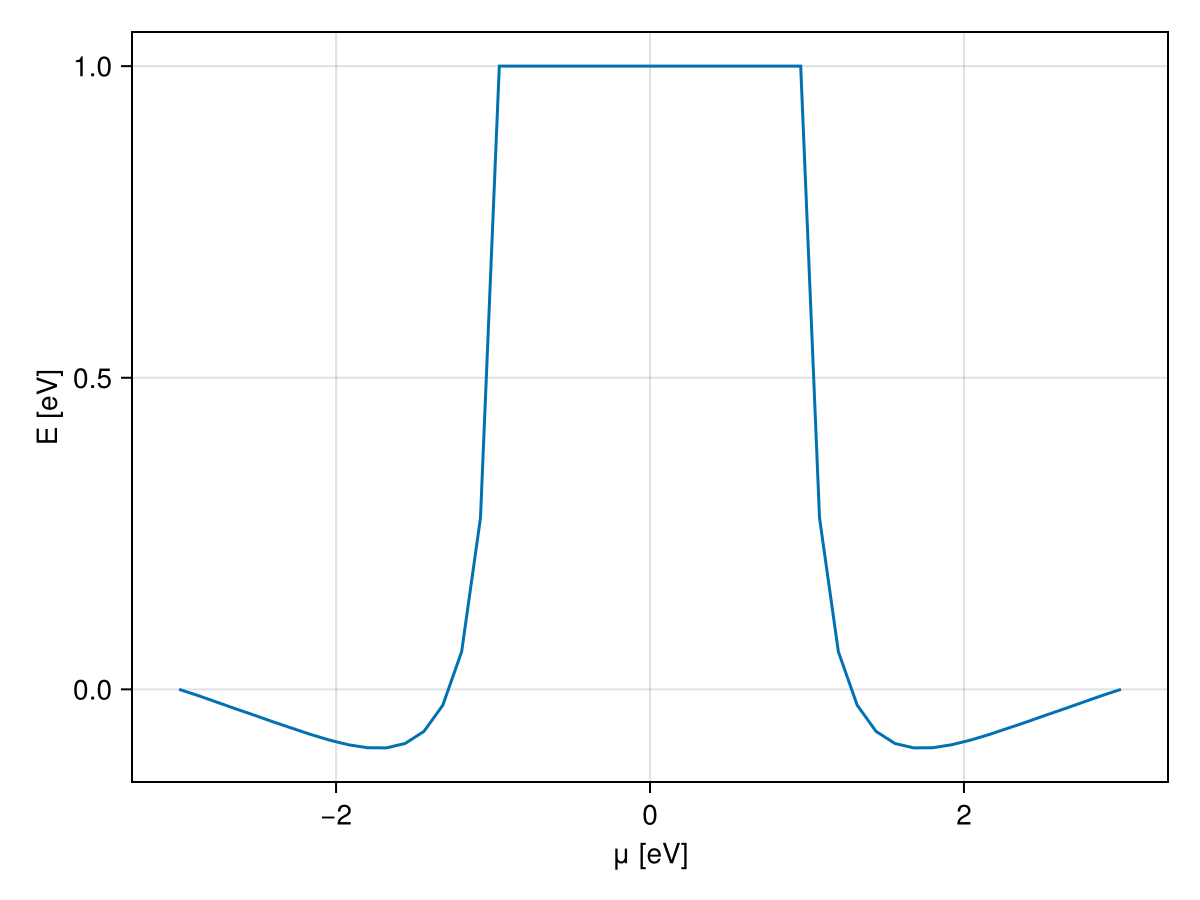

In [272]:
fig = Figure(); ax = Axis(fig[1,1], xlabel = "μ [eV]", ylabel = "E [eV]")
lines!(ax, [m for m in mulist], [i for i in s])
fig

## Orbital Magnetic Momentb

In [ ]:
# in this two band model the OMM is proportional to the Berry curvature via  an e/hbar εn Ωn

In [38]:
"""analytical expression in natural units for the valence band"""
function analytical_omm_CI_conduction(k; a =1, m=1, e=1.0, ħ=1.0)
    kx, ky = k
    sx = sin(kx*a)
    sy = sin(ky*a)
    cx = cos(kx*a)
    cy = cos(ky*a)
    # d vector
    dx = sx
    dy = sy
    dz = m + cx + cy

    d2 = dx^2 + dy^2 + dz^2

    # derivatives of d
    dkx = (a*cx, 0.0, -a*sx)
    dky = (0.0, a*cy, -a*sy)

    # cross product
    cross = (
        dkx[2]*dky[3] - dkx[3]*dky[2],
        dkx[3]*dky[1] - dkx[1]*dky[3],
        dkx[1]*dky[2] - dkx[2]*dky[1]
    )

    # d ⋅ (∂kx d × ∂ky d)
    triple = dx*cross[1] + dy*cross[2] + dz*cross[3]

    mz = -1/2 * triple / d2

    return mz
end

analytical_omm_CI_conduction

In [39]:

using CairoMakie, BZpaths, LinearAlgebra


function omm_bs(a = 1)
    sgnum = 3 # Point group    
    Rs = ([a, 0], [0,a])
    N = 50    #kpoints
    fig = Figure(); ax = Axis(fig[1,1], ylabel = "OMM [e/ħ eV * Å^-2]")
    for i in 1:2
        dispersion(q) = analytical_omm_CI_conduction(q; a =1, m=1, e=1.0, ħ=1.0)
        BZpaths.plot_observable_in_kpath!(ax, dispersion, Rs, sgnum, N)#, high_sym_line high_sym_line = [:Γ, :M, :K, :Γ, :A, :L, :H, :A] )
    end
    fig
end

omm_bs (generic function with 2 methods)

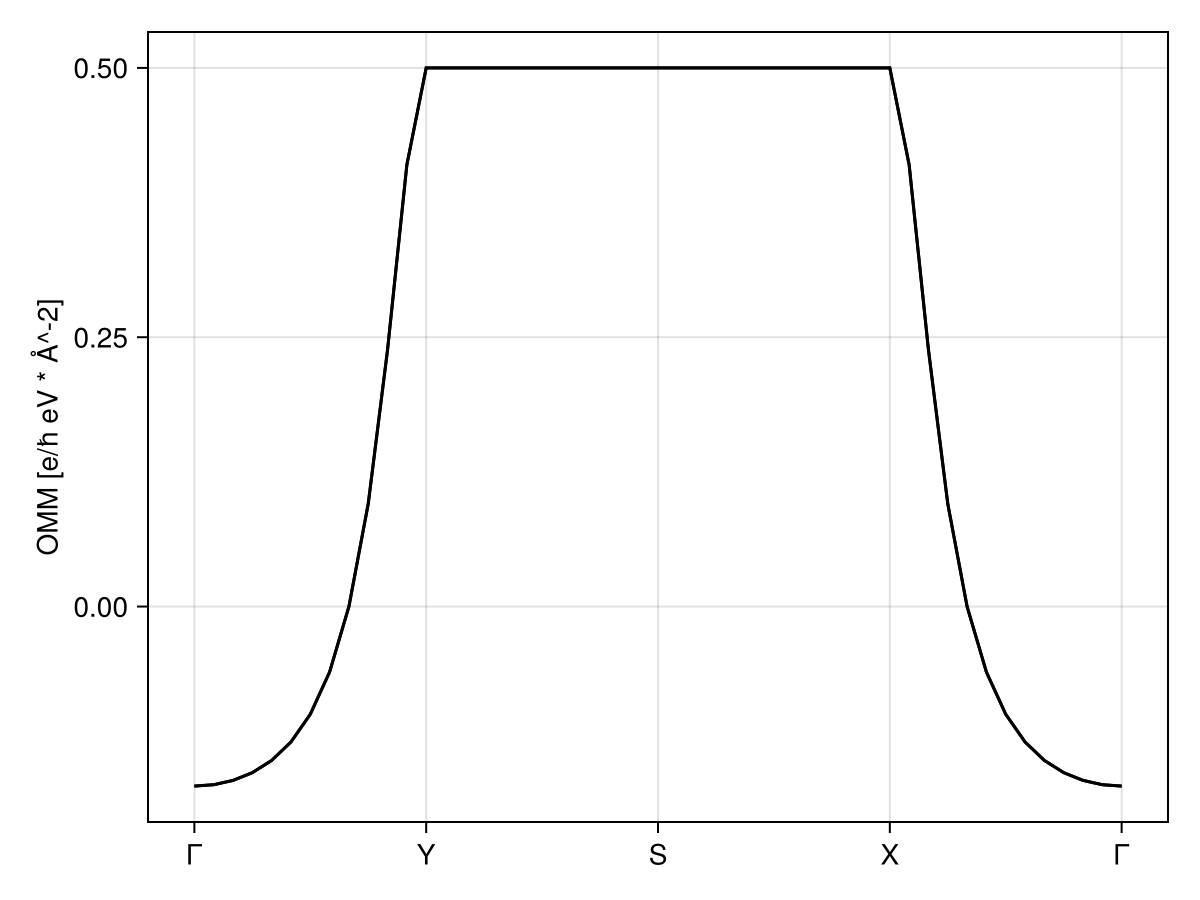

In [40]:
omm_bs()

In [286]:
omm_CI_conduction((0.0,0.0)) 
# consistent mz(0) = e/ħ 1/2 * a^2/(m+2)

0.16666666666666666

### Using Optics_in_the_length_gauge

In [33]:
function omm_q_CI(dir = :z)
    a0 = 1 # Å
    # Rs = ([a0, 0], [0,a0])
    # Gs = dualbasis(Rs)
    h(q) = CI_h(0, q, a0) #in 
    dhx(q) = CI_dh(q, a0,:x)
    dhy(q) = CI_dh(q, a0,:y)
    dhz(q) = CI_dh(q, a0,:z)
    dh(q) = [dhx(q), dhy(q)]
    return OMM_presets(dir, h, dh)
end


omm_q_CI (generic function with 2 methods)

In [35]:
q = [0,1.0]
interband_OMM(omm_q_CI(), q)

2×2 Matrix{ComplexF64}:
 -0.145269-0.0im        0.0+0.0im
       0.0+0.0im  -0.145269-0.0im

In [36]:

using CairoMakie, BZpaths, LinearAlgebra


function omm_analytical_numerical_comp(a = 1)
    sgnum = 3 # Point group    
    Rs = ([a, 0], [0,a])
    N = 50    #kpoints
    fig = Figure(); ax = Axis(fig[1,1], ylabel = "OMM [e/ħ eV * Å^-2]")
    for i in 1:2
        # dispersion(q) = analytical_omm_CI_conduction(q; a =1, m=1, e=1.0, ħ=1.0)
        # BZpaths.plot_observable_in_kpath!(ax, dispersion, Rs, sgnum, N)#, high_sym_line high_sym_line = [:Γ, :M, :K, :Γ, :A, :L, :H, :A] )
        disper(q) = real(interband_OMM(omm_q_CI(), q)[1,1])
        BZpaths.plot_observable_in_kpath!(ax, disper, Rs, sgnum, N)
    end
    fig
end

omm_analytical_numerical_comp (generic function with 2 methods)

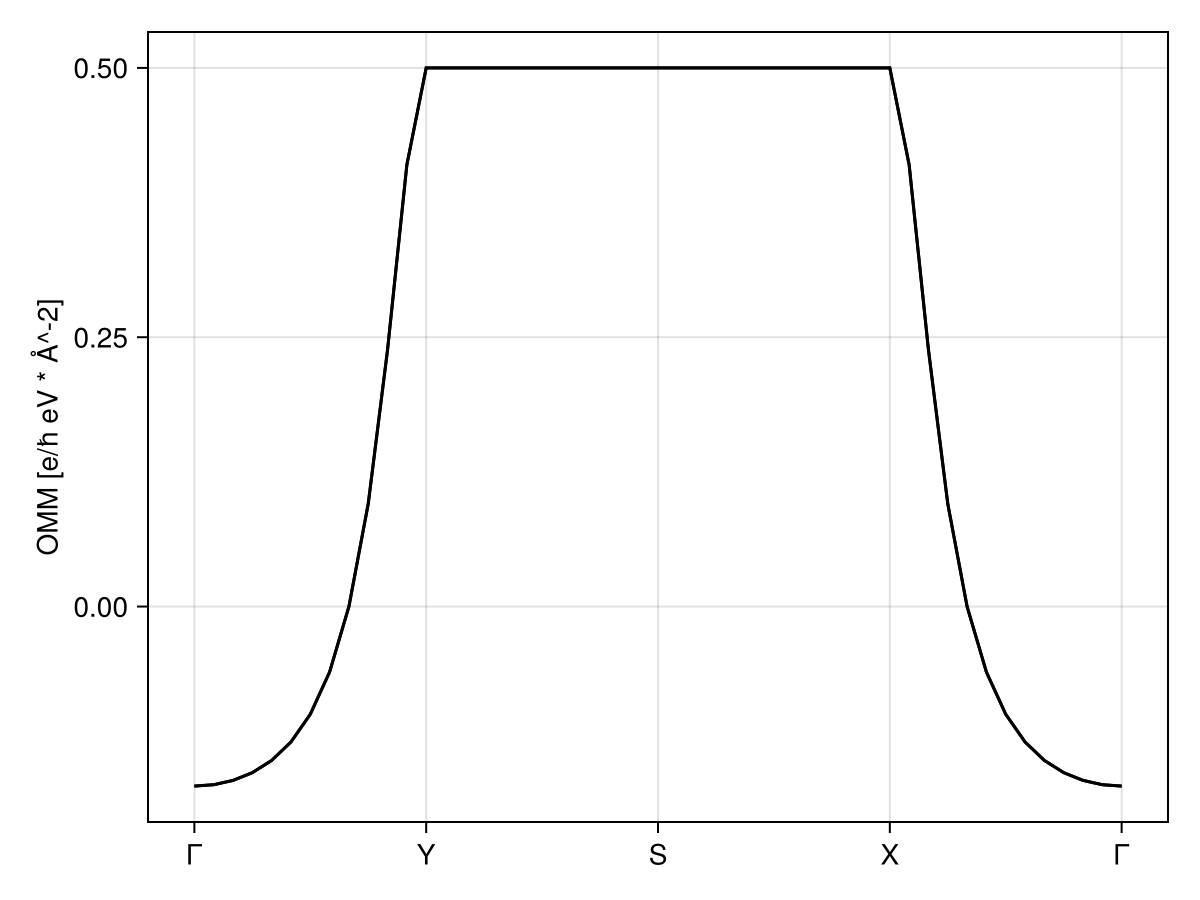

In [37]:
omm_analytical_numerical_comp()

Which coincides with the analytical result

## Deprecated

In [245]:
""" here the bounds are BZ boundaries over /a0 """
function ahe_CI_old(μ; dirj=:x, dirE=:y, T = 1,  evals = 80000)
    a0 = 4.0 # Å
    botbounds = [-π, π]
    topbounds = [-π, π]
    h(q) = CI_h(μ, q, a0) #in 
    dhx(q) = CI_dh(q, a0, :x)
    dhy(q) = CI_dh(q,a0, :y)
    dhz(q) = CI_dh(q,a0, :z)
    dh(q) = [dhx(q), dhy(q)]
    computation = Transport_computation_presets(botbounds,topbounds, evals)
    return AH_presets(a0, dirj, dirE, h, dh, T, computation)
end


ahe_CI_old (generic function with 1 method)

In [246]:
σij_anomalous_hall(ahe_CI_old(0)) 

0.9999999455378722

In [181]:
ahe_CI_old(0)

AH_presets
  a0: Float64 3.0
  dirJ: Symbol x
  dirE: Symbol y
  h: h (function of type var"#h#398"{Int64, Float64})
  dh: dh (function of type var"#dh#402"{var"#dhy#400"{Float64}, var"#dhx#399"{Float64}})
  T: Float64 1.0
  computation: Transport_computation_presets
